In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import plotting

In [2]:
tsla = pd.read_csv("../data/raw/TSLA.csv", parse_dates=["Date"])
spy = pd.read_csv("../data/raw/SPY.csv", parse_dates=["Date"])
bnd = pd.read_csv("../data/raw/BND.csv", parse_dates=["Date"])

In [3]:
prices = pd.DataFrame({
    "TSLA": tsla["Close"],
    "SPY": spy["Close"],
    "BND": bnd["Close"],
})

prices.head()

,TSLA,SPY,BND
0,14.620667,169.687836,59.205635
1,14.006000,166.623352,59.377613
2,14.085333,165.053879,59.549477
3,14.063333,167.110703,59.585312
4,14.041333,170.076065,59.492199


In [4]:
returns = prices.pct_change().dropna()

returns.head()

,TSLA,SPY,BND
1,-0.042041,-0.018060,0.002905
2,0.005664,-0.009419,0.002894
3,-0.001562,0.012462,0.000602
4,-0.001564,0.017745,-0.001563
5,-0.018802,-0.008013,0.001686


In [5]:
cov = risk_models.sample_cov(prices)

cov

,TSLA,SPY,BND
TSLA,0.327140,0.049791,0.001775
SPY,0.049791,0.031142,0.001083
BND,0.001775,0.001083,0.002821


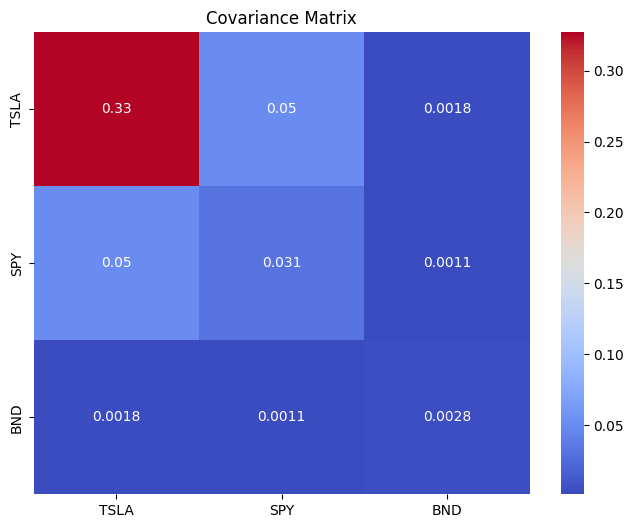

In [6]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cov,
    annot=True,
    cmap="coolwarm"
)

plt.title("Covariance Matrix")

plt.show()

In [7]:
# Compute annualized return from the 10-day forecast window
forecast_start = 406.001953
forecast_end = 407.871185
tsla_10day_return = (forecast_end - forecast_start) / forecast_start
tsla_annualized_return = ((1 + tsla_10day_return) ** (252 / 10)) - 1

# Assign directly into your Series
expected_returns = pd.Series({
    "TSLA": tsla_annualized_return,
    "SPY": returns["SPY"].mean() * 252,
    "BND": returns["BND"].mean() * 252,
})


In [8]:
ef = EfficientFrontier(
    expected_returns,
    cov
)

weights = ef.max_sharpe()

clean_weights = ef.clean_weights()

clean_weights

OrderedDict([('TSLA', 0.0), ('SPY', 0.45643), ('BND', 0.54357)])

In [9]:
performance = ef.portfolio_performance(verbose=True)

Expected annual return: 7.7%
Annual volatility: 8.9%
Sharpe Ratio: 0.87


In [10]:
ef2 = EfficientFrontier(
    expected_returns,
    cov
)

weights2 = ef2.min_volatility()

ef2.clean_weights()

OrderedDict([('TSLA', 0.0), ('SPY', 0.05467), ('BND', 0.94533)])

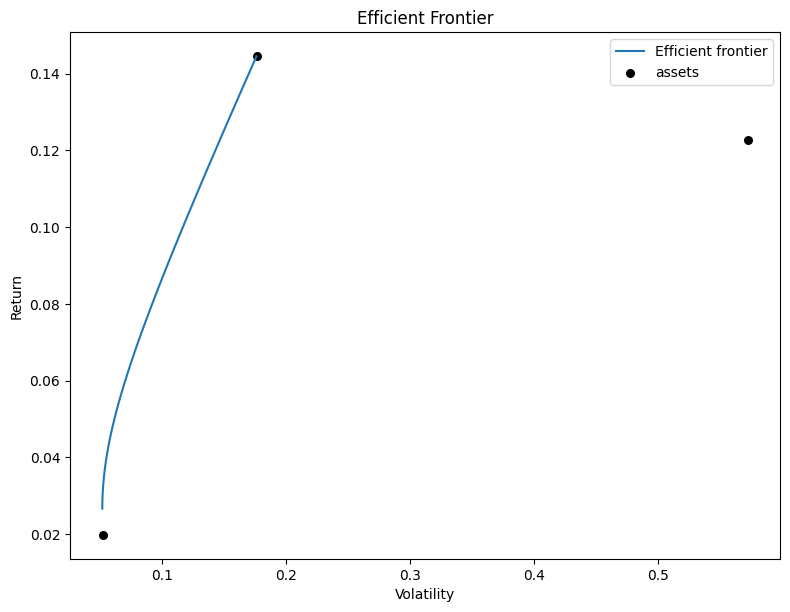

In [12]:
# Create a fresh optimizer
ef_plot = EfficientFrontier(expected_returns, cov)

fig, ax = plt.subplots(figsize=(8,6))

plotting.plot_efficient_frontier(
    ef_plot,
    ax=ax,
    show_assets=True
)

plt.title("Efficient Frontier")
plt.show()